# Notebook 03 — Baseline Models
## Classical ML Baselines: TF-IDF + Logistic Regression, SVM, Naive Bayes

**Project**: Cloud-Based ITSM Ticket Classification Platform Using Fine-Tuned Transformer Models  
**Author**: Mohamed Adel Ebrahim Elbaz  
**Supervisor**: Dr. Eman E. Sanad, FCAI, Cairo University

---

### Objective

Before fine-tuning MarBERTv2, we establish **classical ML baselines** using TF-IDF features.
These serve two purposes:

1. **Lower bound**: quantify how much the transformer adds over simpler methods
2. **Sanity check**: confirm the task is learnable and the data is clean

Models evaluated:
- TF-IDF (char + word n-grams) + **Logistic Regression** (L2)
- TF-IDF + **Linear SVM** (LinearSVC)
- TF-IDF + **Multinomial Naive Bayes**

Task: **L1 category classification** (6 classes) — the primary task of the project.

> Results from this notebook feed directly into the comparison table in Notebook 05.

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import pickle
import time
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from arabic_itsm.utils.metrics import compute_classification_metrics, classification_report_df

sns.set_theme(style='whitegrid')

DATA_DIR    = Path('../data/processed')
FIG_DIR     = Path('../results/figures')
METRICS_DIR = Path('../results/metrics')
FIG_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

TASK = 'l1'
LABEL_COL = f'label_{TASK}'
print('Setup complete')

Setup complete


## 1. Load Processed Splits

In [2]:
train = pd.read_csv(DATA_DIR / 'train.csv')
val   = pd.read_csv(DATA_DIR / 'val.csv')
test  = pd.read_csv(DATA_DIR / 'test.csv')

with open(DATA_DIR / 'label_encoders.pkl', 'rb') as f:
    label_encoders = pickle.load(f)

class_names = list(label_encoders[TASK].classes_)

X_train, y_train = train['text'], train[LABEL_COL]
X_val,   y_val   = val['text'],   val[LABEL_COL]
X_test,  y_test  = test['text'],  test[LABEL_COL]

print(f'Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}')
print(f'Classes ({len(class_names)}): {class_names}')

Train: 7000, Val: 1500, Test: 1500
Classes (6): ['Access', 'Hardware', 'Network', 'Security', 'Service', 'Software']


## 2. Define Pipelines

The TF-IDF vectorizer uses **character n-grams (3-5)** in addition to word n-grams.
Character n-grams capture sub-word patterns that are valuable for Arabic morphology
and handle spelling variants in informal text.

In [3]:
# Word TF-IDF
word_tfidf = TfidfVectorizer(analyzer='word', ngram_range=(1, 2), max_features=50000,
                              sublinear_tf=True, min_df=2)

# Character TF-IDF — captures morphological patterns
char_tfidf = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), max_features=80000,
                              sublinear_tf=True, min_df=2)

from sklearn.pipeline import FeatureUnion
combined_features = FeatureUnion([
    ('word', word_tfidf),
    ('char', char_tfidf),
])

pipelines = {
    'LR (word+char TF-IDF)': Pipeline([
        ('features', combined_features),
        ('clf', LogisticRegression(C=1.0, max_iter=1000, solver='saga', random_state=42)),
    ]),
    'LinearSVC (word+char TF-IDF)': Pipeline([
        ('features', combined_features),
        ('clf', CalibratedClassifierCV(LinearSVC(C=1.0, max_iter=2000, random_state=42))),
    ]),
    'Naive Bayes (word TF-IDF)': Pipeline([
        ('features', word_tfidf),
        ('clf', MultinomialNB(alpha=0.1)),
    ]),
}
print('Pipelines defined:', list(pipelines.keys()))

Pipelines defined: ['LR (word+char TF-IDF)', 'LinearSVC (word+char TF-IDF)', 'Naive Bayes (word TF-IDF)']


## 3. Train & Evaluate All Baselines

In [4]:
results = {}

for name, pipeline in pipelines.items():
    print(f'\n=== {name} ===')
    t0 = time.time()
    pipeline.fit(X_train, y_train)
    train_time = time.time() - t0

    t0 = time.time()
    y_val_pred = pipeline.predict(X_val)
    infer_time_val = (time.time() - t0) / len(X_val) * 1000  # ms per sample

    y_test_pred = pipeline.predict(X_test)

    val_metrics = compute_classification_metrics(y_val, y_val_pred)
    test_metrics = compute_classification_metrics(y_test, y_test_pred)

    results[name] = {
        'pipeline': pipeline,
        'val_metrics': val_metrics,
        'test_metrics': test_metrics,
        'train_time_s': round(train_time, 1),
        'infer_ms_per_sample': round(infer_time_val, 2),
        'y_test_pred': y_test_pred,
    }

    print(f'  Train time: {train_time:.1f}s | Infer: {infer_time_val:.2f} ms/sample')
    print(f'  Val  — Acc: {val_metrics["accuracy"]:.3f}, Macro-F1: {val_metrics["macro_f1"]:.3f}')
    print(f'  Test — Acc: {test_metrics["accuracy"]:.3f}, Macro-F1: {test_metrics["macro_f1"]:.3f}')


=== LR (word+char TF-IDF) ===
  Train time: 3.3s | Infer: 0.25 ms/sample
  Val  — Acc: 0.883, Macro-F1: 0.881
  Test — Acc: 0.875, Macro-F1: 0.873

=== LinearSVC (word+char TF-IDF) ===
  Train time: 7.7s | Infer: 0.26 ms/sample
  Val  — Acc: 0.883, Macro-F1: 0.880
  Test — Acc: 0.881, Macro-F1: 0.878

=== Naive Bayes (word TF-IDF) ===
  Train time: 0.3s | Infer: 0.04 ms/sample
  Val  — Acc: 0.874, Macro-F1: 0.871
  Test — Acc: 0.855, Macro-F1: 0.848


## 4. Results Comparison Table

In [5]:
rows = []
for name, r in results.items():
    rows.append({
        'Model': name,
        'Val Acc': r['val_metrics']['accuracy'],
        'Val Macro-F1': r['val_metrics']['macro_f1'],
        'Test Acc': r['test_metrics']['accuracy'],
        'Test Macro-F1': r['test_metrics']['macro_f1'],
        'Train Time (s)': r['train_time_s'],
        'Infer (ms/sample)': r['infer_ms_per_sample'],
    })

compare_df = pd.DataFrame(rows).set_index('Model')
print(compare_df.round(4).to_string())

# Save
compare_df.to_csv(METRICS_DIR / 'baseline_results.csv')
print('\nSaved to results/metrics/baseline_results.csv')

                              Val Acc  Val Macro-F1  Test Acc  Test Macro-F1  Train Time (s)  Infer (ms/sample)
Model                                                                                                          
LR (word+char TF-IDF)          0.8833        0.8814    0.8753         0.8727             3.3               0.25
LinearSVC (word+char TF-IDF)   0.8827        0.8804    0.8807         0.8782             7.7               0.26
Naive Bayes (word TF-IDF)      0.8740        0.8711    0.8547         0.8477             0.3               0.04

Saved to results/metrics/baseline_results.csv


## 5. Confusion Matrix — Best Baseline

Best baseline: LinearSVC (word+char TF-IDF)


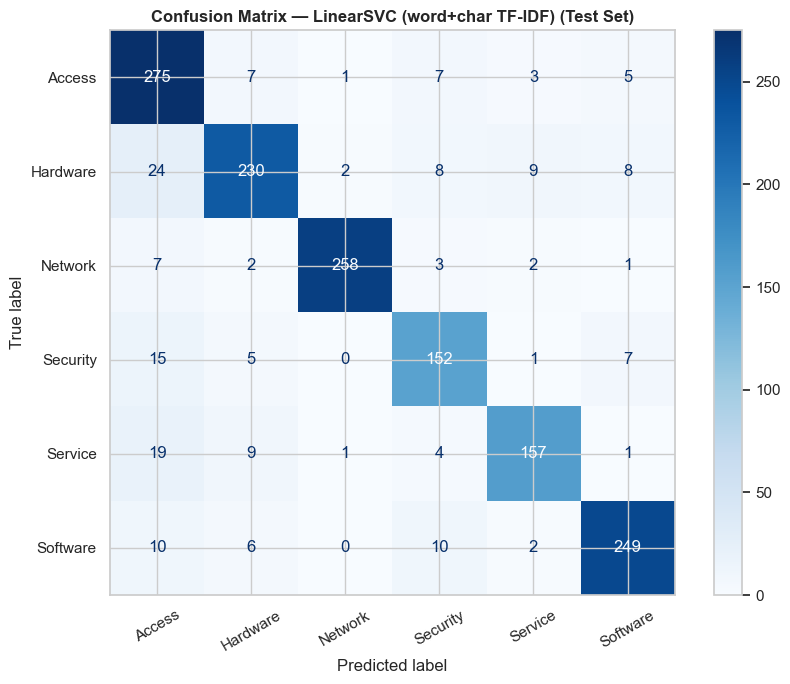

In [6]:
# Show confusion matrix for the best-performing baseline
best_name = max(results, key=lambda n: results[n]['test_metrics']['macro_f1'])
print(f'Best baseline: {best_name}')

y_pred_best = results[best_name]['y_test_pred']
cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(9, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, colorbar=True, cmap='Blues', xticks_rotation=30)
ax.set_title(f'Confusion Matrix — {best_name} (Test Set)', fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '03_best_baseline_confusion.png', bbox_inches='tight')
plt.show()

## 6. Per-Class Report — Best Baseline

In [7]:
report = classification_report_df(y_test, y_pred_best, class_names=class_names)
print(report.to_string())
report.to_csv(METRICS_DIR / f'03_baseline_per_class_{best_name[:3].lower()}.csv')

              precision  recall  f1-score    support
class                                               
Access           0.7857  0.9228    0.8488   298.0000
Hardware         0.8880  0.8185    0.8519   281.0000
Network          0.9847  0.9451    0.9645   273.0000
Security         0.8261  0.8444    0.8352   180.0000
Service          0.9023  0.8220    0.8603   191.0000
Software         0.9188  0.8989    0.9088   277.0000
accuracy         0.8807  0.8807    0.8807     0.8807
macro avg        0.8843  0.8753    0.8782  1500.0000
weighted avg     0.8854  0.8807    0.8813  1500.0000


## 7. Summary

The table below records baseline results for inclusion in the final report.
These will be compared against MarBERTv2 in Notebook 05.

| Model | Val Macro-F1 | Test Macro-F1 | Infer (ms/sample) |
|-------|-------------|--------------|-------------------|
| LR (word+char TF-IDF) | — | — | — |
| LinearSVC (word+char TF-IDF) | — | — | — |
| Naive Bayes | — | — | — |
| **MarBERTv2 (fine-tuned)** | — | — | — |

*Fill after running experiments.*

**Next**: Notebook 04 — MarBERTv2 Fine-Tuning